# Nama: Rendi Rahmat Saputra
# NIM: 4222301023
# Kelas: RE - 06 A PAGI 

In [31]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

## Load Our Dataset

In [32]:
df = pd.read_csv('berat_tinggi.csv')

## EDA

Text(0.5, 1.0, 'Sebaran Nilai berat vs tinggi')

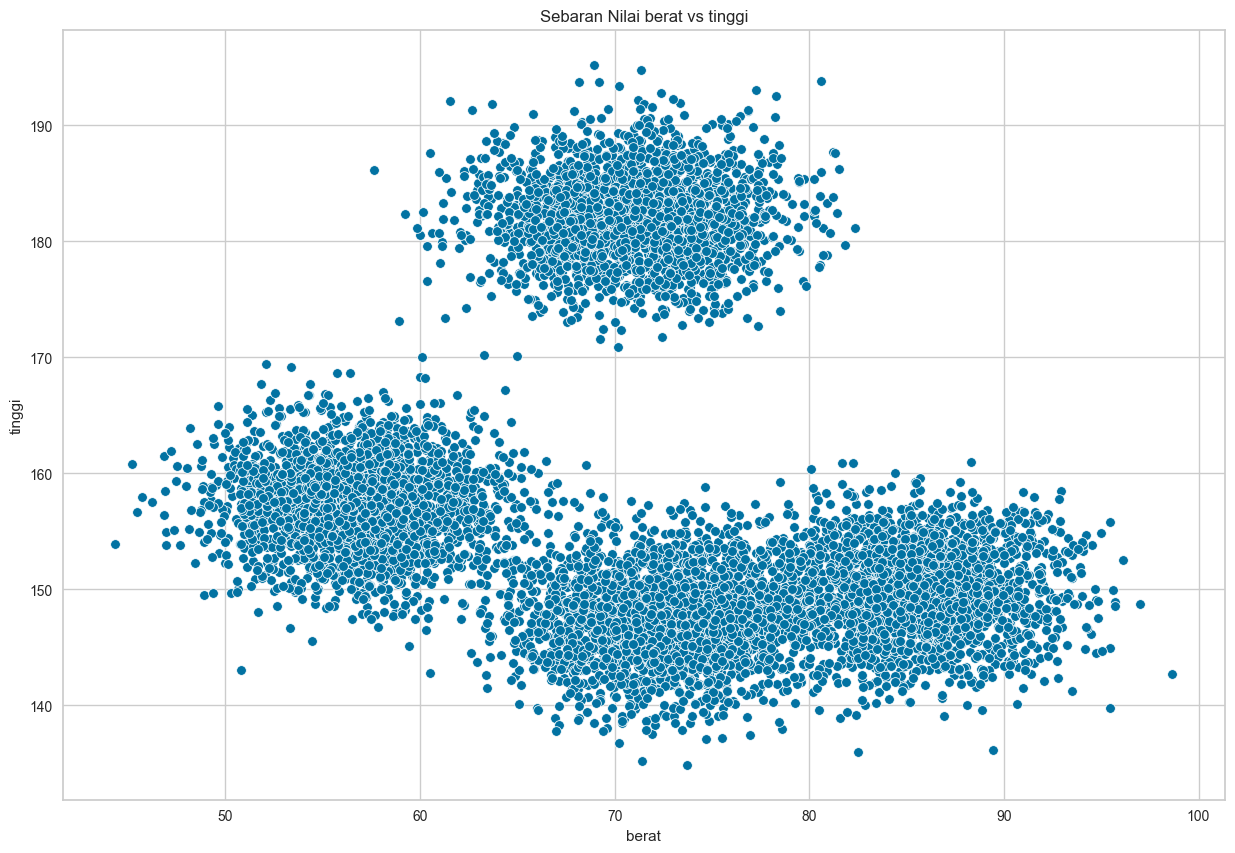

In [33]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df, x='berat', y='tinggi')
plt.title('Sebaran Nilai berat vs tinggi')

In [34]:
df.describe()

,tinggi,berat
count,8888.000000,8888.000000
mean,159.125498,71.365302
std,14.258305,10.729120
min,134.881305,44.344643
25%,148.522565,63.557079
50%,153.805704,71.748643
75%,170.365514,79.003827
max,195.232920,98.644868


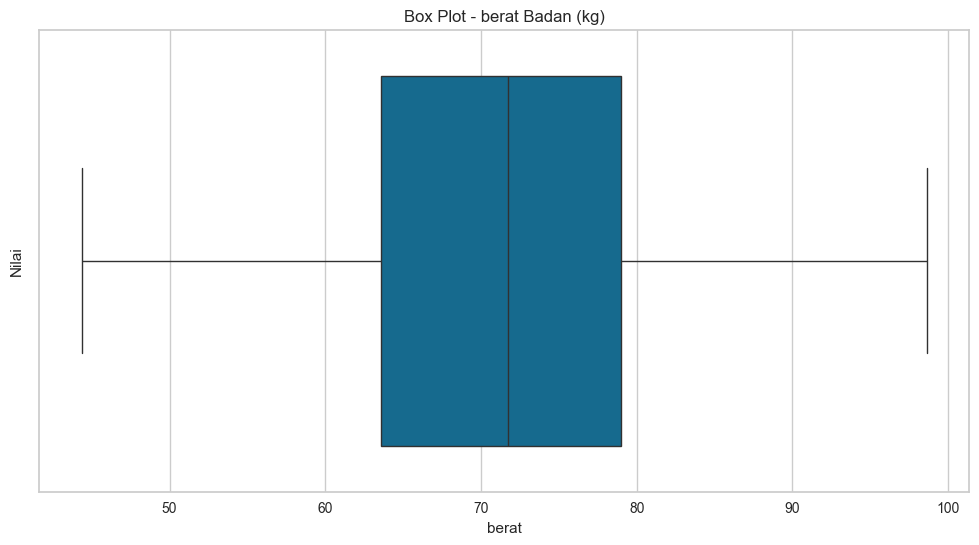

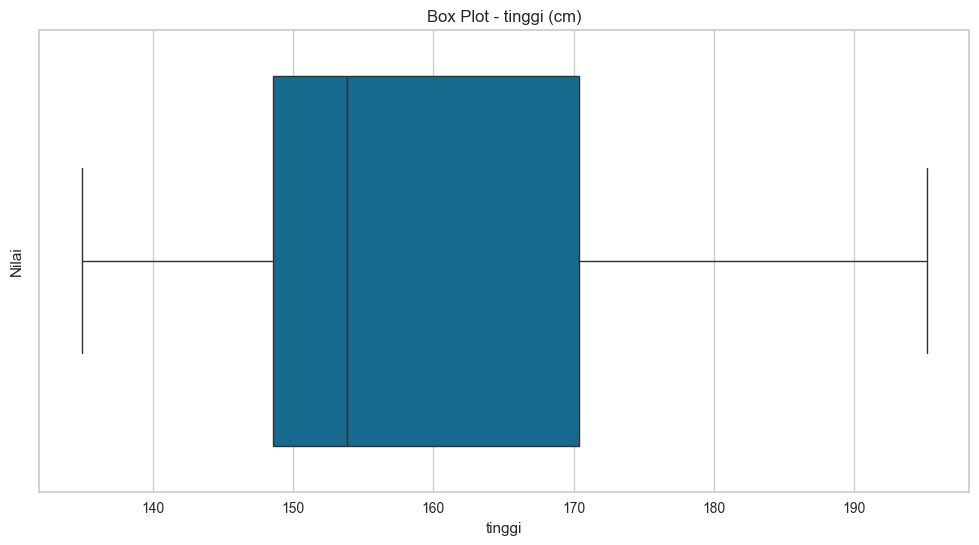

In [35]:
# Looping untuk kolom 'berat' dan 'tinggi'
columns = ['berat', 'tinggi']

for col in columns:
    # Box plot
    plt.figure(figsize=(12, 6))
    sns.boxplot(x=col, data=df)
    plt.title(f'Box Plot - {col} Badan (kg)' if col == 'berat' else f'Box Plot - {col} (cm)')
    plt.xlabel(col)
    plt.ylabel('Nilai')
    plt.show()

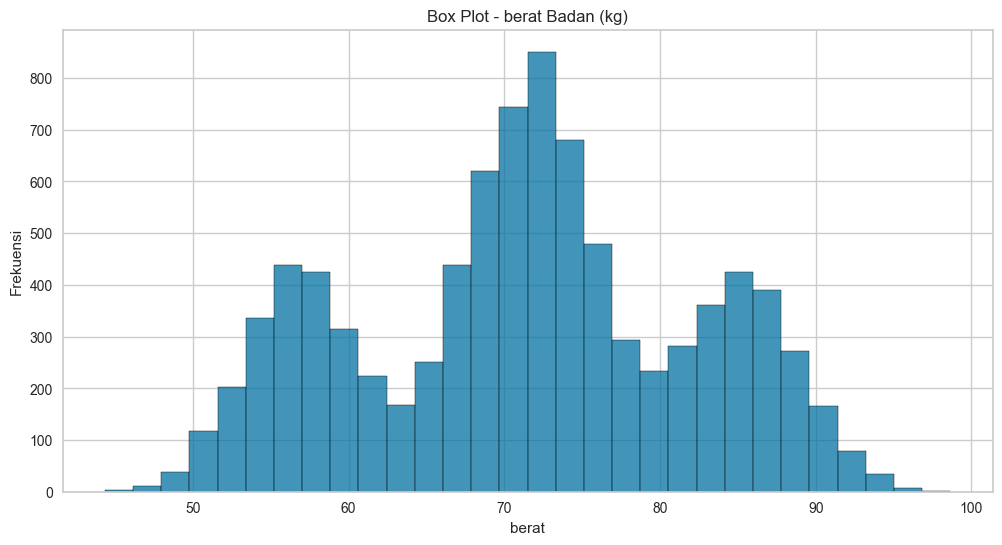

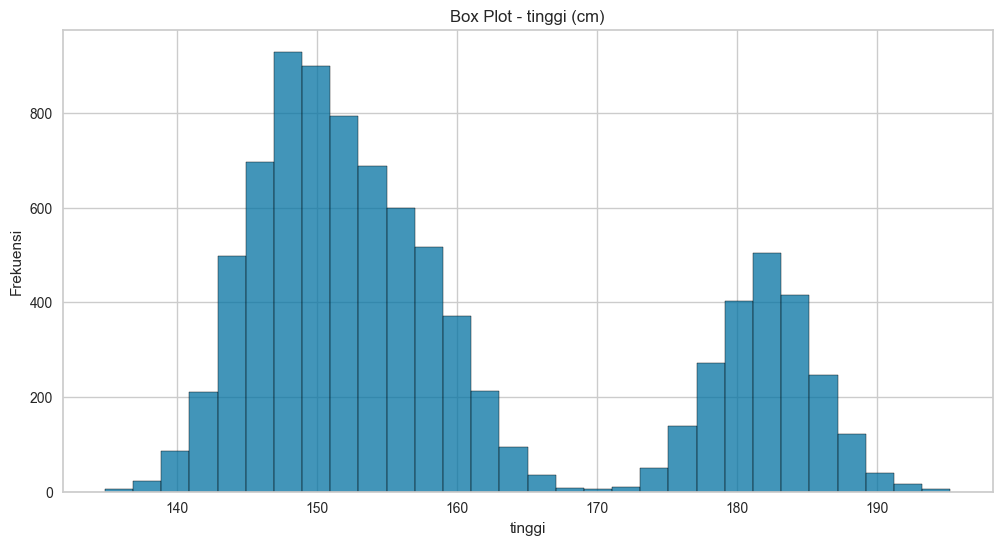

In [36]:
for col in columns:
    # Histogram
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], bins=30, kde=False)
    plt.title(f'Box Plot - {col} Badan (kg)' if col == 'berat' else f'Box Plot - {col} (cm)')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
    plt.show()

## Feature Engineering
* Unsupervised tidak perlu dilakukan splitting
1. Drop Duplikat
2. Outlier Handling (opsional)-> pada step ini tidak perlu, karena berat dan tinggi masih wajar untuk nilai seperti itu
3. Feature Scalling

In [37]:
# Drop Duplicates

print(f"Dataframe dimension before duplication drop {df.shape[0]}")

df = df.drop_duplicates().reset_index(drop=True)

print(f"Dataframe dimension after duplication drop {df.shape[0]}")

Dataframe dimension before duplication drop 8888
Dataframe dimension after duplication drop 8888


dari hasil running program diatas, tidak ada data yg duplikat

In [38]:
fitur_columns = ['berat', 'tinggi']
X = df[fitur_columns].values
y = df['deskripsi'].values #anotator label

In [39]:
# Feature Scalling
from sklearn.preprocessing import StandardScaler
X_std = StandardScaler().fit_transform(X)
df_scalling = pd.DataFrame(data = X_std, columns = fitur_columns )
df_scalling.describe()

,berat,tinggi
count,8.888000e+03,8.888000e+03
mean,-9.465376e-16,9.953034e-17
std,1.000056e+00,1.000056e+00
min,-2.518583e+00,-1.700451e+00
25%,-7.278008e-01,-7.436739e-01
50%,3.573103e-02,-3.731224e-01
75%,7.119833e-01,7.883579e-01
max,2.542716e+00,2.532521e+00


In [40]:
X_std

array([[-1.2118229 , -0.07092171],
       [-1.75281897,  0.08546572],
       [-0.87900786,  0.16556767],
       ...,
       [-0.89346332, -0.02015625],
       [-1.6141688 , -0.17762697],
       [ 1.40264032, -0.3111536 ]], shape=(8888, 2))

In [41]:
df_scalling

,berat,tinggi
0,-1.211823,-0.070922
1,-1.752819,0.085466
2,-0.879008,0.165568
3,-0.216544,1.636598
4,-0.002258,1.777105
...,...,...
8883,0.329937,1.274490
8884,0.905892,-0.527475
8885,-0.893463,-0.020156
8886,-1.614169,-0.177627


## TO DO!
- Lengkapi Code dibawah ini, untuk mengecek distribusi sebelum dan setelah dilakukan feature scalling menggunakan standar scaller

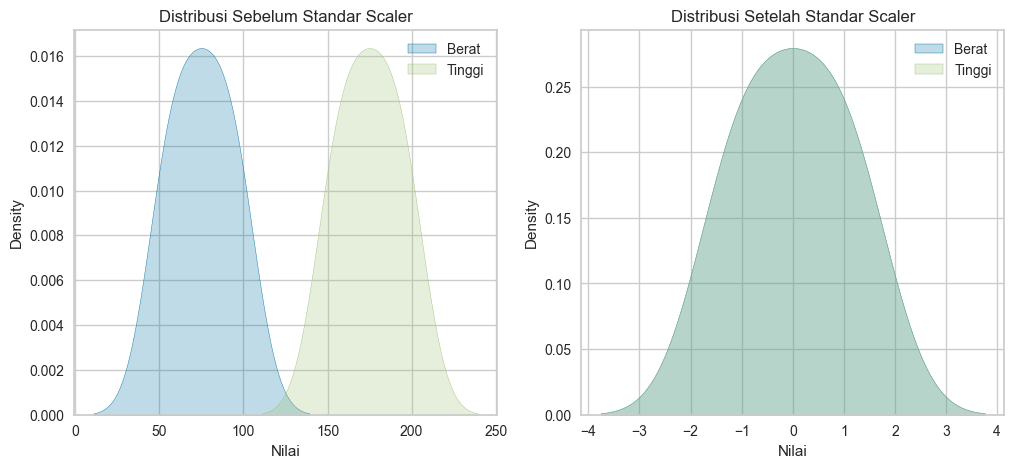

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Contoh data
df = pd.DataFrame({
    'berat': [50, 60, 70, 80, 90, 100],
    'tinggi': [150, 160, 170, 180, 190, 200]
})

# Scaling
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Plot distribusi sebelum Standar Scaler (Isi dibawah ini)
ax1.set_title('Distribusi Sebelum Standar Scaler')
sns.kdeplot(df['berat'], ax=ax1, label='Berat', fill=True)
sns.kdeplot(df['tinggi'], ax=ax1, label='Tinggi', fill=True)

# Plot distribusi setelah Standar Scaler (Isi dibawah ini)
ax2.set_title('Distribusi Setelah Standar Scaler')
sns.kdeplot(df_scaled['berat'], ax=ax2, label='Berat', fill=True)
sns.kdeplot(df_scaled['tinggi'], ax=ax2, label='Tinggi', fill=True)

# Set x-labels
ax1.set_xlabel('Nilai')
ax2.set_xlabel('Nilai')

# Menampilkan legenda
ax1.legend()
ax2.legend()

plt.show()


### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Dari hasil di atas menunjukkan bahwa setelah dilakukan Standard Scaler, distribusi variabel berat dan tinggi tetap mempertahankan bentuk sebaran aslinya, namun keduanya berada pada skala yang sama sehingga analisis menjadi seimbang dan tidak ada variabel yang mendominasi.

## K-means Clustering
Pada pembahasan kali ini akan diuji 2 metode pemilihan nilai cluster (K) yang terbaik, mendekati distribusi pada label anotator.
1. Metode Elbow
2. Via-Score plot

### Metode Elbow

Text(0, 0.5, 'Intertia / WSS')

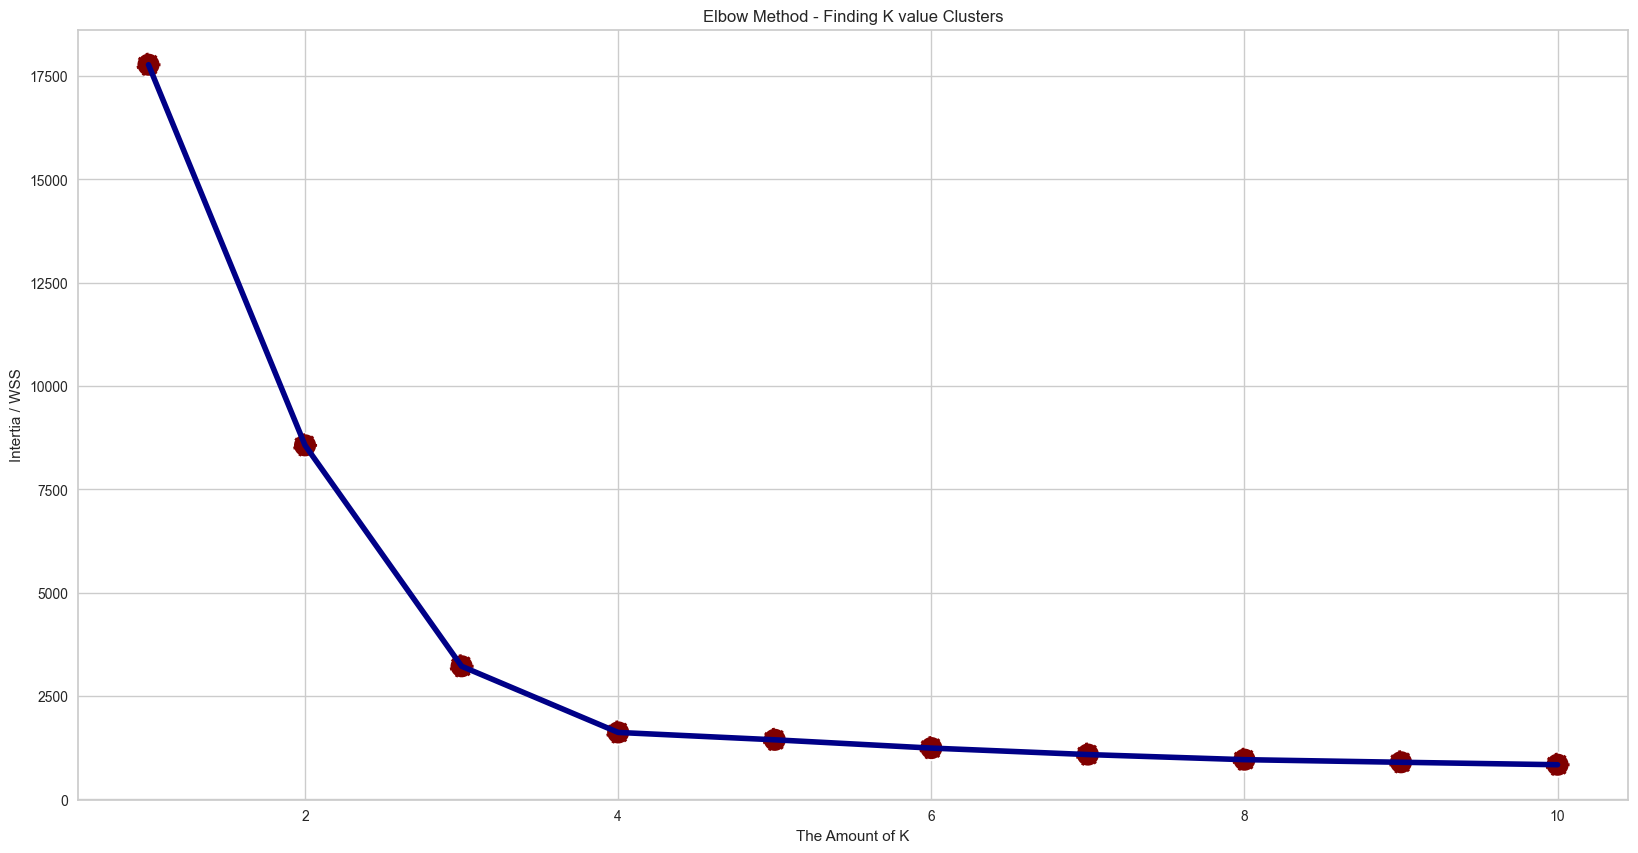

In [43]:
from sklearn.cluster import KMeans
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(df_scalling.values)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(20, 10))

sns.lineplot(x=range(1, 11), y=inertia, color='#000087', linewidth = 4)
sns.scatterplot(x=range(1, 11), y=inertia, s=300, color='#800000',  linestyle='--')
plt.title('Elbow Method - Finding K value Clusters')
plt.xlabel('The Amount of K')
plt.ylabel('Intertia / WSS')

In [44]:
#Dari hasil diatas elbow nya dipilih pada angka 4,
# karena titik awal sebelum titik selanjutnya memiliki gap yang konstan atau
# titik setelah lekukan tajam sebelum mendatar
from sklearn.cluster import KMeans
kmeans_elbow = KMeans(n_clusters=3, random_state=42)
kmeans_elbow.fit(df_scalling.values)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [45]:
# Lalu assign cluster
df_scalling['cluster_elbow'] = kmeans_elbow.labels_


In [46]:
df

,berat,tinggi
0,50,150
1,60,160
2,70,170
3,80,180
4,90,190
5,100,200


<Axes: xlabel='berat', ylabel='tinggi'>

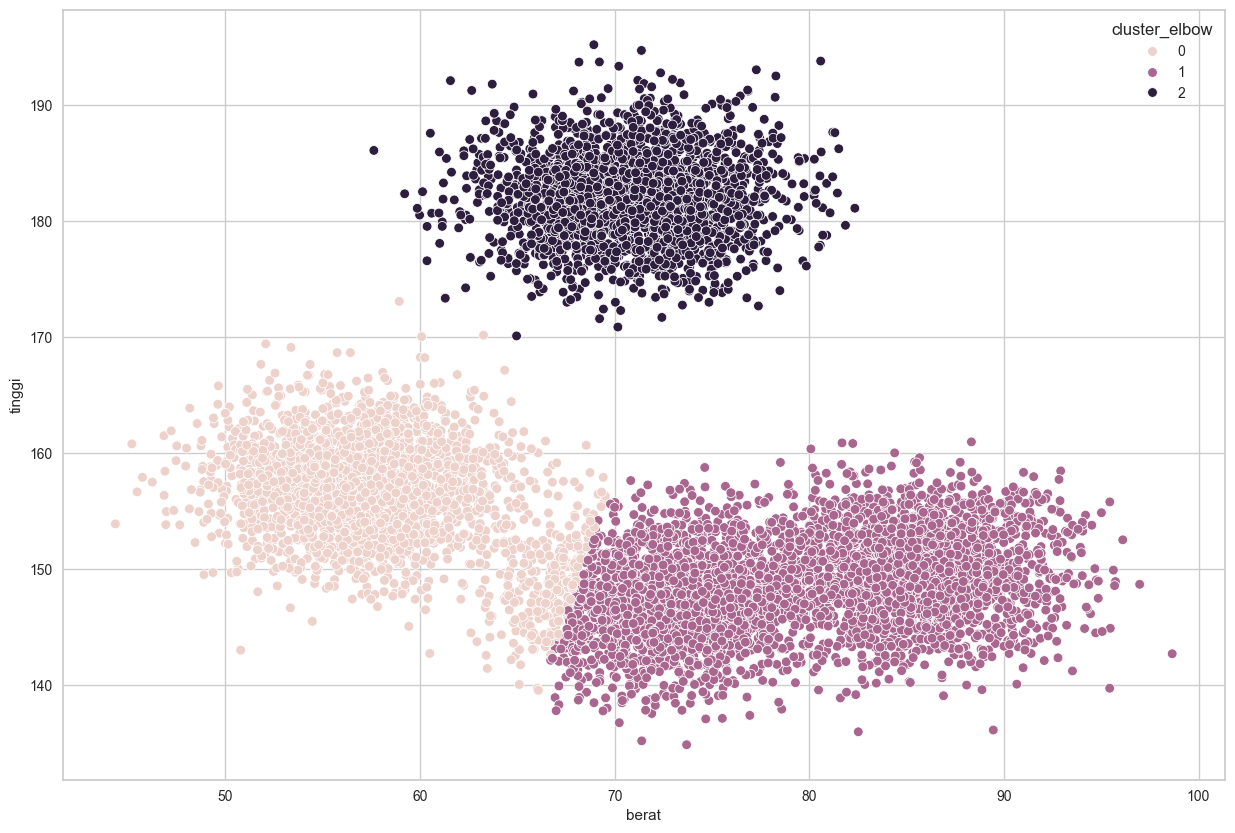

In [47]:
df_full_plot = pd.read_csv('berat_tinggi.csv')
df_full_plot = df_full_plot.drop_duplicates().reset_index(drop=True)
df_full_plot['cluster_elbow'] = kmeans_elbow.labels_

fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df_full_plot, x='berat', y='tinggi', hue='cluster_elbow')

### Bandingkan hasil dengan label anotator

<Axes: xlabel='berat', ylabel='tinggi'>

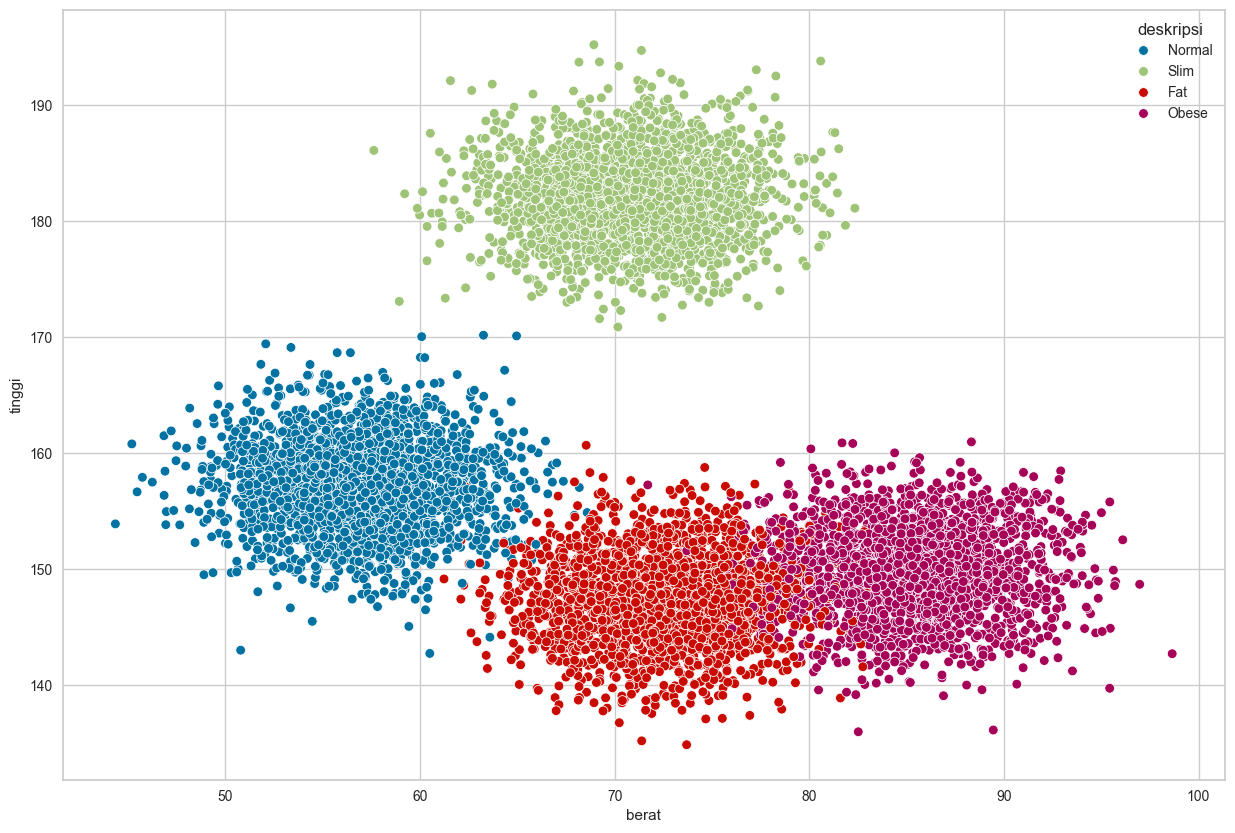

In [48]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df_full_plot, x='berat', y='tinggi',hue='deskripsi')

### Hasil diatas ketika menggunakan elbow ialah optimal, karena cluster cocok dengan label anotator yang telah tersedia di deskripsi. Dengan kondisi :
1. Cluster 0 -> Normal
2. Cluster 1 -> Fat
3. Cluster 2 -> Slim
4. Cluster 3 -> Obese

### 2. Via Score Plot

In [49]:
pip install yellowbrick

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


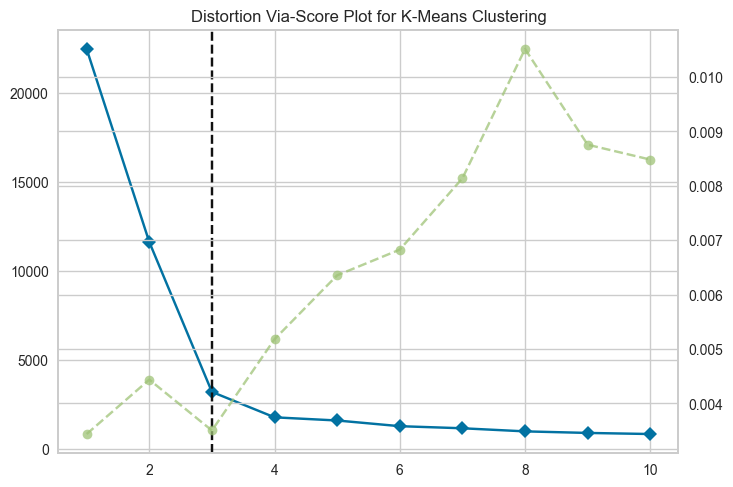

In [50]:
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

k_means_via = KMeans(random_state=42)
visualizer = KElbowVisualizer(k_means_via, k=(1,11), timings=True, force_model=True)
visualizer.fit(df_scalling.values)
plt.title('Distortion Via-Score Plot for K-Means Clustering')
plt.show()

In [51]:
# Dari hasil diatas K-nya dipilih pada angka 3,
# karena titik distorsinya bertemu pada nilai 3 di sumbu x
from sklearn.cluster import KMeans
kmeans_via = KMeans(n_clusters=3, random_state=0)
kmeans_via.fit(df_scalling.values)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [55]:
#taruh hasil k-means via score method ke df dengan nama kolom cluster_via
df_scalling['cluster_via'] = kmeans_via.labels_
df_full_plot['cluster_via'] = kmeans_via.labels_

In [56]:
df

,berat,tinggi
0,50,150
1,60,160
2,70,170
3,80,180
4,90,190
5,100,200


## TO DO !
- Lakukan evaluasi pada k-means menggunakan via score secara visualisasi

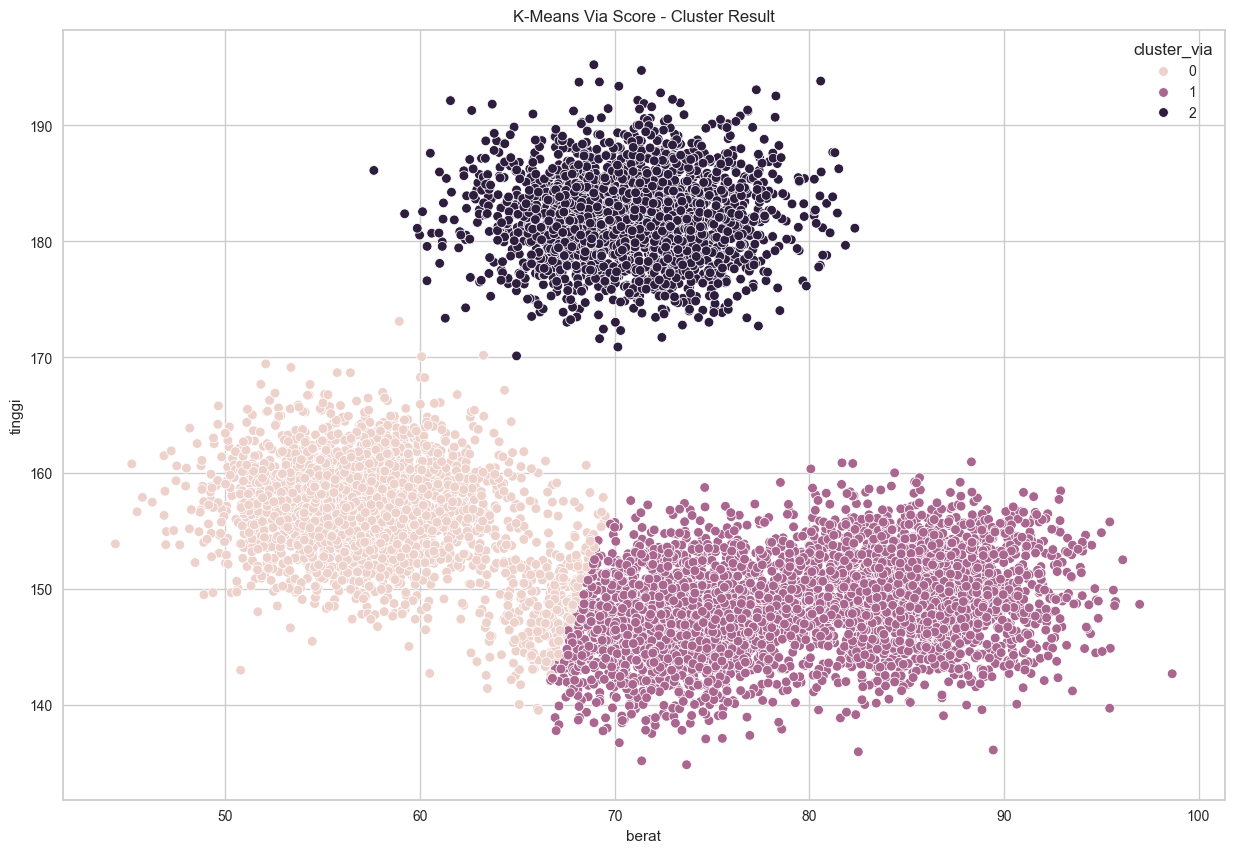

In [58]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df_full_plot, x='berat', y='tinggi', hue='cluster_via')
plt.title('K-Means Via Score - Cluster Result')
plt.show()

### Bandingkan dengan label anotator

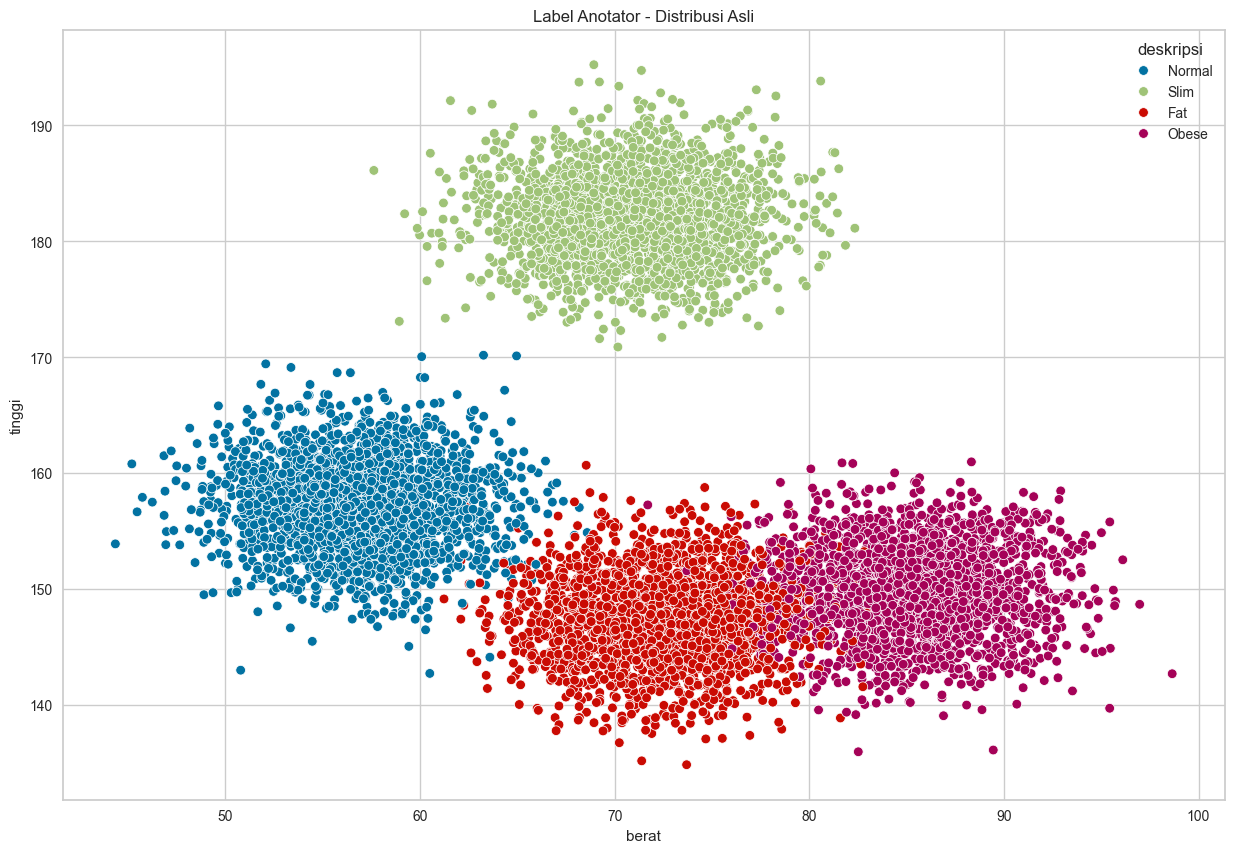

In [59]:
fig, ax = plt.subplots(figsize=(15,10))
sns.scatterplot(data=df_full_plot, x='berat', y='tinggi', hue='deskripsi')
plt.title('Label Anotator - Distribusi Asli')
plt.show()

### Tulis Interpretasi dari hasil evaluasi diatas :
### Isi disini
1. Hasil clustering K-Means Via Score (k=3) menghasilkan pengelompokan berat dan tinggi badan yang secara visual selaras dengan distribusi label anotator, di mana setiap cluster merepresentasikan kategori yang bermakna yaitu Normal, Fat, dan Slim.
2. Perbandingan scatter plot cluster Via Score dengan label anotator menunjukkan bahwa algoritma K-Means mampu menemukan pola pengelompokan secara mandiri tanpa supervisi, dengan tingkat kesesuaian yang tinggi terhadap klasifikasi yang telah ditentukan secara manual oleh anotator.


### Thank you :)